# Fusion evaluation

Evaluates **the first video in `out/`** (alphabetically, named `<method>_<source>.mp4`) against its source
frames in `data/<source>/rgb/` (visible) and `data/<source>/ir/` (infrared). For now the source is always the
car clip.

1. **Human perception**: a snapshot (visible | infrared | fused) for one frame, and edge preservation
   (Q^AB/F) over the clip: how much of the edge information in *each* source survives in the fused image,
   how much is lost, and how much is artefact.
2. **Tracking**: the dataset ships a ground-truth box for the car every 10th frame (`rgb.txt`, `ir.txt`).
   A learned single-stream tracker (ViT) is initialised from the first box and run over the visible, infrared
   and fused video; its predictions are scored against the ground truth at every annotated frame. A good
   fusion should track at least as well as the better of its inputs.

> **Scope.** This compares *fused vs. each modality alone* through a single-stream tracker. It does **not**
> test against the state of the art for this data, which is a multi-modal tracker fed both streams directly
> (e.g. HMFT, the VTUAV baseline). That is the ceiling a pixel-level fusion should eventually be compared to.

In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
OUT = Path("out")
EVAL = OUT / "evaluation"

SOURCE = "car_008"        # !Find reference with lower VL visibility!
SNAPSHOT_FRAME = 75       # index into the clip; 75 = middle of the 150-frame sample

TRACKER_MODEL = Path("models/object_tracking_vittrack_2023sep.onnx")  # ViT tracker weights, downloaded on first use
IOU_THRESHOLD = 0.5       # a frame counts as a success if IoU >= this
CENTER_THRESHOLD = 20     # px; a frame counts as precise if centre error <= this

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

## Helpers

In [2]:
def pick(*candidates):
    return next(p for p in candidates if p.exists())


def frames(path):
    """Yield BGR frames from a video file or a directory of images (sorted by name)."""
    if path.is_dir():
        for f in sorted(p for p in path.iterdir() if p.suffix.lower() in IMAGE_EXTS):
            yield cv2.imread(str(f))
        return
    cap = cv2.VideoCapture(str(path))
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                return
            yield frame
    finally:
        cap.release()


def read_frame(path, index):
    for i, f in enumerate(frames(path)):
        if i == index:
            return f
    raise IndexError(f"no frame {index} in {path}")


def count_frames(path):
    return sum(1 for _ in frames(path))


def label(img, text):
    img = img.copy()
    cv2.putText(img, text, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 0, 0), 6, cv2.LINE_AA)
    cv2.putText(img, text, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 255, 255), 2, cv2.LINE_AA)
    return img


def load_boxes(txt):
    """Ground truth: one 'x y w h' line per annotated frame."""
    return np.loadtxt(txt, delimiter=None).reshape(-1, 4)


def iou(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ix = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    iy = max(0, min(ay + ah, by + bh) - max(ay, by))
    inter = ix * iy
    return inter / (aw * ah + bw * bh - inter + 1e-9)


def center_error(a, b):
    return float(np.hypot((a[0] + a[2] / 2) - (b[0] + b[2] / 2), (a[1] + a[3] / 2) - (b[1] + b[3] / 2)))


TRACKER_URL = "https://github.com/opencv/opencv_zoo/raw/main/models/object_tracking_vittrack/object_tracking_vittrack_2023sep.onnx"


def make_tracker():
    """OpenCV zoo's VitTrack: a learned transformer tracker."""
    if not TRACKER_MODEL.exists():
        import urllib.request
        TRACKER_MODEL.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(TRACKER_URL, TRACKER_MODEL)
    params = cv2.TrackerVit_Params()
    params.net = str(TRACKER_MODEL)
    return cv2.TrackerVit.create(params)


def track(path, init_box):
    """Run the tracker over every frame of `path`; returns one box per frame (None once lost)."""
    boxes = []
    tracker = None
    for i, frame in enumerate(frames(path)):
        if i == 0:
            tracker = make_tracker()
            tracker.init(frame, tuple(int(round(v)) for v in init_box))
            boxes.append(tuple(init_box))
            continue
        ok, box = tracker.update(frame)
        boxes.append(tuple(box) if ok else None)
    return boxes


def score(pred_boxes, gt_boxes, stride):
    """Compare predictions with the ground truth at every annotated frame."""
    rows = []
    for k, gt in enumerate(gt_boxes):
        i = k * stride
        if i >= len(pred_boxes):
            break
        p = pred_boxes[i]
        rows.append(dict(frame=i, iou=iou(p, gt) if p else 0.0, center_error=center_error(p, gt) if p else np.inf))
    return pd.DataFrame(rows)


def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)


def edge_preservation(a, b, f):
    """Xydeas & Petrovic Q^AB/F, plus Petrovic's loss L^AB/F and artefact N^AB/F (Q + L + N = 1).

    a, b: the two source images (grayscale); f: the fused image (grayscale).
    Q = share of the sources' edge information (strength + orientation) that reached the fused image.
    L = share lost (fused edge weaker than the sources).  N = share that is artefact (fused edge
    stronger than both sources, i.e. not explained by either).
    """
    def grad(img):
        sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        return np.hypot(sx, sy), np.arctan2(sy, sx)

    def q(gs, als, gf, alf):
        """Per-pixel edge-preservation of one source in the fused image."""
        with np.errstate(divide="ignore", invalid="ignore"):
            G = np.where(gs > gf, gf / gs, gs / gf)
        G = np.nan_to_num(G, nan=0.0)                      # both zero -> no edge, no credit
        A = 1 - np.minimum(np.abs(als - alf), 2 * np.pi - np.abs(als - alf)) / np.pi
        Qg = 0.9994 / (1 + np.exp(-15 * (G - 0.5)))
        Qa = 0.9879 / (1 + np.exp(-22 * (A - 0.8)))
        return Qg * Qa

    ga, ala = grad(a)
    gb, alb = grad(b)
    gf, alf = grad(f)
    qaf, qbf = q(ga, ala, gf, alf), q(gb, alb, gf, alf)
    wa, wb = ga, gb                                        # weight each pixel by its source edge strength
    total = (wa + wb).sum()
    lost = (gf < ga) | (gf < gb)                           # fused edge weaker than a source
    artefact = (gf > ga) & (gf > gb)                       # fused edge stronger than both sources
    Q = (qaf * wa + qbf * wb).sum() / total
    L = (lost * ((1 - qaf) * wa + (1 - qbf) * wb)).sum() / total
    N = (artefact * ((1 - qaf) * wa + (1 - qbf) * wb)).sum() / total
    return Q, L, N

## Input: the first fused video in `out/`

In [3]:
VISIBLE = pick(DATA / SOURCE / "visible.mp4", DATA / SOURCE / "rgb")
THERMAL = pick(DATA / SOURCE / "thermal.mp4", DATA / SOURCE / "ir")
GT_VISIBLE = load_boxes(DATA / SOURCE / "rgb.txt")
GT_THERMAL = load_boxes(DATA / SOURCE / "ir.txt")

video = sorted(OUT.glob(f"*_{SOURCE}.mp4"))[0]  # the first one alphabetically, i.e. top of the folder listing
method = video.stem[: -len(SOURCE) - 1]

n_frames = count_frames(video)
stride = round(count_frames(VISIBLE) / len(GT_VISIBLE))  # frames between ground-truth boxes
print(f"video:   {video.name}  ({n_frames} frames)")
print(f"method:  {method}")
print(f"ground truth: {len(GT_VISIBLE)} boxes, one every {stride} frames")

video:   dtcwt_car_008.mp4  (150 frames)
method:  dtcwt
ground truth: 15 boxes, one every 10 frames


## Human perception

### Snapshot: visible | infrared | fused

wrote out/evaluation/dtcwt_car_008_frame75.png


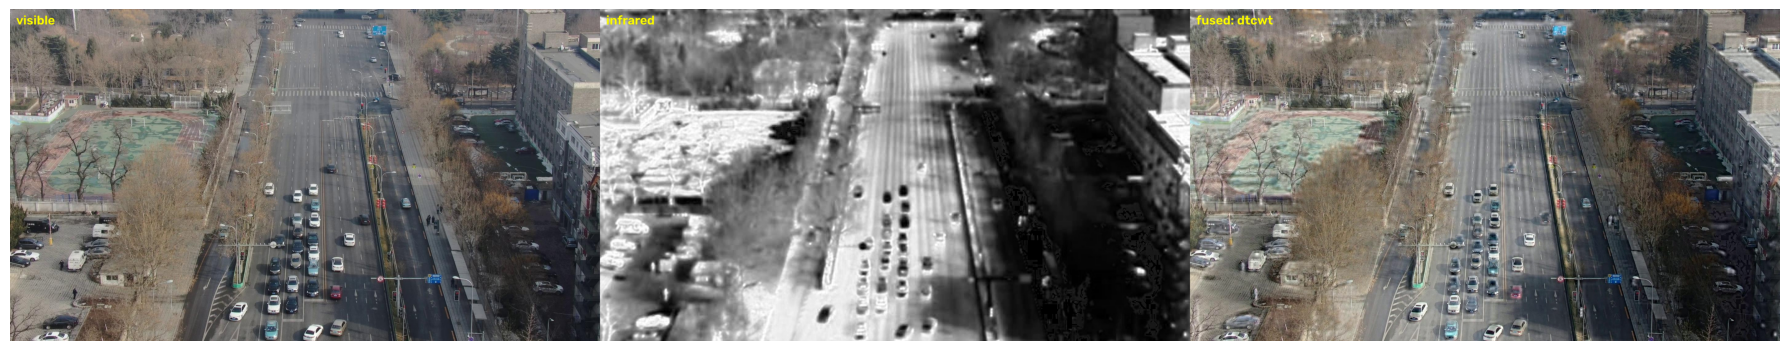

In [4]:
EVAL.mkdir(parents=True, exist_ok=True)

v, t, f = (read_frame(p, SNAPSHOT_FRAME) for p in (VISIBLE, THERMAL, video))
strip = np.hstack([label(v, "visible"), label(t, "infrared"), label(f, f"fused: {method}")])
snapshot_path = EVAL / f"{video.stem}_frame{SNAPSHOT_FRAME}.png"
cv2.imwrite(str(snapshot_path), strip)
print("wrote", snapshot_path)

plt.figure(figsize=(18, 4))
plt.imshow(cv2.cvtColor(strip, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.tight_layout()

### Edge preservation: Q^AB/F

Computed at every annotated frame and averaged. For reference the same measure is applied to the two
inputs themselves: treating the visible image as the "fusion" scores 1 against itself and ~0 against the
infrared, so its Q^AB/F shows how much of the total edge information one modality alone carries. A useful
fusion should exceed both inputs on Q, with low N (artefacts: halos, ringing, noise).

| | meaning |
|---|---|
| **Q^AB/F** | share of source edge information (strength and orientation) transferred to the fused image |
| **L^AB/F** | share lost |
| **N^AB/F** | share that is artefact, not present in either source |

In [5]:
annotated = range(0, min(count_frames(VISIBLE), n_frames), stride)
fv, ft, ff = (list(frames(p)) for p in (VISIBLE, THERMAL, video))

rows = []
for name, stream in (("visible", fv), ("infrared", ft), ("fused", ff)):
    qln = np.array([edge_preservation(to_gray(fv[i]), to_gray(ft[i]), to_gray(stream[i])) for i in annotated])
    rows.append(dict(stream=name, Qabf=qln[:, 0].mean(), Labf=qln[:, 1].mean(), Nabf=qln[:, 2].mean()))

edges = pd.DataFrame(rows).set_index("stream")
edges.to_csv(EVAL / f"{video.stem}_edge_preservation.csv")
print(f"{method}, {SOURCE}, mean over {len(annotated)} frames")
edges.round(3)

dtcwt, car_008, mean over 15 frames


,Qabf,Labf,Nabf
stream,,,
visible,0.671,0.170,0.000
infrared,0.376,0.550,0.000
fused,0.612,0.274,0.114


## Tracking

Same initial box, three videos, one learned single-stream tracker (OpenCV zoo's VitTrack, a transformer
tracker: close to what an automated pipeline would run). Scores at the annotated frames:

- **mean IoU** - overlap between predicted and ground-truth box
- **success** - fraction of annotated frames with IoU >= `IOU_THRESHOLD`
- **precision** - fraction with centre error <= `CENTER_THRESHOLD` px
- **lost at** - first annotated frame where the target was lost (IoU = 0), if any

Not tested here: a multi-modal tracker that takes both streams (the state of the art on VTUAV).

In [6]:
streams = {
    "visible":  (VISIBLE, GT_VISIBLE),
    "infrared": (THERMAL, GT_THERMAL),
    "fused":    (video,   GT_VISIBLE),   # fused frames share the visible image's geometry
}

per_frame = {}
summary = []
for name, (path, gt) in streams.items():
    df = score(track(path, gt[0]), gt, stride)
    per_frame[name] = df
    lost = df.loc[df.iou == 0, "frame"]
    summary.append(dict(
        stream=name,
        mean_iou=df.iou.mean(),
        success=(df.iou >= IOU_THRESHOLD).mean(),
        precision=(df.center_error <= CENTER_THRESHOLD).mean(),
        lost_at=int(lost.iloc[0]) if len(lost) else None,
    ))

summary = pd.DataFrame(summary).set_index("stream")
summary.to_csv(EVAL / f"{video.stem}_tracking.csv")
print(f"ViT tracker, {method}, {SOURCE}")
summary.round(3)

[ WARN:0@18.522] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


[ WARN:0@19.469] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


[ WARN:0@20.233] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


ViT tracker, dtcwt, car_008


,mean_iou,success,precision,lost_at
stream,,,,
visible,0.638,0.933,1.0,None
infrared,0.652,0.733,1.0,None
fused,0.746,1.000,1.0,None


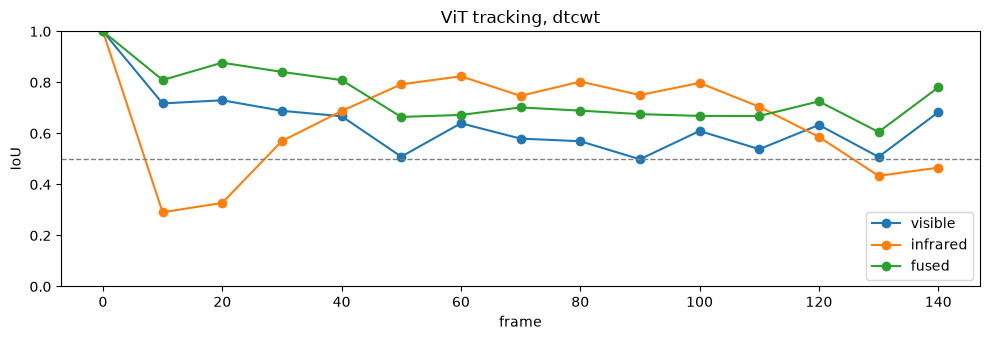

In [7]:
plt.figure(figsize=(10, 3.5))
for name, df in per_frame.items():
    plt.plot(df.frame, df.iou, marker="o", label=name)
plt.axhline(IOU_THRESHOLD, color="grey", ls="--", lw=1)
plt.xlabel("frame"); plt.ylabel("IoU"); plt.ylim(0, 1); plt.legend(); plt.title(f"ViT tracking, {method}")
plt.tight_layout()